# Skenario 3 — Hyperparameter Tuning & Ensemble
**Tujuan:** Hyperparameter tuning (epoch, batch size, learning rate, dropout) lalu ensemble majority voting

**Task:** Klasifikasi Emosi (5 kelas) dan Sentimen (3 kelas)

---
**Strategi hemat RAM:** Setiap kombinasi hyperparameter × model dilatih satu per satu, hasilnya langsung di-save ke `results_s3.json`.

**🏆 Best model:** Model + tokenizer terbaik per task (across semua HP config) di-save ke `/kaggle/working/best_model_s3_{task}/`

## 0. Install & Import

In [1]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip("transformers[torch]", "datasets", "accelerate", "scikit-learn",
    "imbalanced-learn", "seaborn", "matplotlib",
    "pandas", "numpy", "torch")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 74.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import os, re, json, warnings, random, time, gc
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset as HFDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


## 1. Load & Preprocessing Dataset

In [3]:
DATA_PATH = "/kaggle/input/datasets/carameyyow/secondary/PRDECT-ID Dataset_clean.csv"

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

print("Shape :", df.shape)
print("Kolom :", df.columns.tolist())
display(df.head(3))

Shape : (5400, 16)
Kolom : ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion', 'Location_grouped', 'review_text', 'review_char_len', 'review_word_len', 'review_tokens']


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion,Location_grouped,review_text,review_char_len,review_word_len,review_tokens
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy,Jakarta Utara,Alhamdulillah berfungsi dengan baik. Packaging...,100,14,"['alhamdulillah', 'berfungsi', 'baik', 'packag..."
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy,Kota Tangerang Selatan,"barang bagus dan respon cepat, harga bersaing ...",61,10,"['barang', 'bagus', 'respon', 'cepat', 'harga'..."
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy,Jakarta Barat,"barang bagus, berfungsi dengan baik, seler ram...",66,9,"['barang', 'bagus', 'berfungsi', 'baik', 'sele..."


In [4]:
def clean_text(text: str):
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["Customer Review"].apply(clean_text)

le_sent = LabelEncoder()
le_emot = LabelEncoder()

df["label_sentiment"] = le_sent.fit_transform(df["Sentiment"])
df["label_emotion"]   = le_emot.fit_transform(df["Emotion"])

print("Label Sentimen :", dict(zip(le_sent.classes_, le_sent.transform(le_sent.classes_))))
print("Label Emosi    :", dict(zip(le_emot.classes_, le_emot.transform(le_emot.classes_))))

display(
    df[
        [
            "Customer Review",
            "text_clean",
            "Sentiment",
            "label_sentiment",
            "Emotion",
            "label_emotion",
        ]
    ].head(4)
)

TASKS = {
    "Emotion": ("text_clean", "label_emotion", le_emot.classes_),
    "Sentiment": ("text_clean", "label_sentiment", le_sent.classes_),
}

Label Sentimen : {'Negative': np.int64(0), 'Positive': np.int64(1)}
Label Emosi    : {'Anger': np.int64(0), 'Fear': np.int64(1), 'Happy': np.int64(2), 'Love': np.int64(3), 'Sadness': np.int64(4)}


,Customer Review,text_clean,Sentiment,label_sentiment,Emotion,label_emotion
0,Alhamdulillah berfungsi dengan baik. Packaging...,alhamdulillah berfungsi dengan baik packaging ...,Positive,1,Happy,2
1,"barang bagus dan respon cepat, harga bersaing ...",barang bagus dan respon cepat harga bersaing d...,Positive,1,Happy,2
2,"barang bagus, berfungsi dengan baik, seler ram...",barang bagus berfungsi dengan baik seler ramah...,Positive,1,Happy,2
3,bagus sesuai harapan penjual nya juga ramah. t...,bagus sesuai harapan penjual nya juga ramah tr...,Positive,1,Happy,2


## 2. Helper Functions

In [5]:
def make_splits(texts, labels, test_size=0.2, val_size=0.1):
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=test_size, random_state=SEED, stratify=labels)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size/(1-test_size), random_state=SEED, stratify=y_train)
    return X_train, X_val, X_test, y_train, y_val, y_test


def build_hf_dataset(texts, labels, tokenizer, max_len=128):
    enc = tokenizer(list(texts), truncation=True, padding="max_length",
                    max_length=max_len, return_tensors="pt")
    return HFDataset.from_dict({
        "input_ids":      enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels":         list(labels),
    })


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }


def train_and_evaluate(model_name, train_ds, val_ds, test_texts, test_labels,
                       tokenizer, num_labels, label_names,
                       output_dir="./tmp_model",
                       num_epochs=3, batch_size=16, lr=2e-5,
                       weight_decay=0.01, dropout=None,
                       warmup_ratio=0.1, max_len=128):
    import time
    actual_batch_size = min(batch_size, 8) 
    grad_accum = batch_size // actual_batch_size if batch_size >= 8 else 1

    print(f"      [System] Target Batch: {batch_size} -> Run with Actual Batch: {actual_batch_size}, Grad Accum: {grad_accum}")

    while True:
        try:
            for attempt in range(3):
                try:
                    model = AutoModelForSequenceClassification.from_pretrained(
                        model_name, num_labels=num_labels, ignore_mismatched_sizes=True)
                    break
                except Exception as e:
                    if attempt == 2:
                        raise e
                    print(f"  ⚠️ Gagal download model {model_name}, mencoba lagi ({attempt+2}/3) dalam 5 detik... (Error: {e})")
                    time.sleep(5)

            if dropout is not None and hasattr(model.config, "hidden_dropout_prob"):
                model.config.hidden_dropout_prob = dropout
                model.config.attention_probs_dropout_prob = dropout

            args = TrainingArguments(
                output_dir=output_dir,
                num_train_epochs=num_epochs,
                per_device_train_batch_size=actual_batch_size, 
                per_device_eval_batch_size=actual_batch_size,
                gradient_accumulation_steps=grad_accum,      
                learning_rate=lr,
                weight_decay=weight_decay,
                warmup_ratio=warmup_ratio,
                eval_strategy="epoch",
                save_strategy="epoch",
                save_total_limit=1,
                save_only_model=True,
                load_best_model_at_end=True,
                metric_for_best_model="f1_macro",
                logging_steps=50,
                fp16=(DEVICE == "cuda"),
                report_to="none",
                seed=SEED,
            )

            trainer = Trainer(
                model=model,
                args=args,
                train_dataset=train_ds,
                eval_dataset=val_ds,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
            )

            t0 = time.time()
            trainer.train()
            elapsed = time.time() - t0
            break
            
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"  ⚠️ [OOM] CUDA OOM dengan actual_batch={actual_batch_size}, grad_accum={grad_accum}.")
                if 'trainer' in locals():
                    del trainer
                if 'model' in locals():
                    del model
                free_memory()
                
                # Kalau masih OOM di batch 8, turunin lagi ke 4, naikin grad_accum 2x lipat
                actual_batch_size = actual_batch_size // 2
                grad_accum = grad_accum * 2
                
                if actual_batch_size < 2:
                    print("  ❌ [OOM] Batch size sudah minimum (< 2). Gagal melatih model ini.")
                    raise e
                print(f"  🔄 Mencoba ulang dengan actual_batch={actual_batch_size}, grad_accum={grad_accum}...")
            else:
                raise e

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer, max_len)
    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)

    metrics = {
        "accuracy":    round(accuracy_score(test_labels, preds), 4),
        "f1_macro":    round(f1_score(test_labels, preds, average="macro"), 4),
        "f1_weighted": round(f1_score(test_labels, preds, average="weighted"), 4),
        "train_time_s": round(elapsed, 1),
    }
    report = classification_report(test_labels, preds, target_names=label_names)
    return trainer, metrics, report, preds

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def save_best_model(trainer, tokenizer, task_name, model_alias, model_name,
                    hp_label, hyperparams, metrics, label_names, skenario="3"):
    """Simpan model + tokenizer + metadata ke folder best_model_s{skenario}_{task}."""
    best_dir = f"/kaggle/working/best_model_s{skenario}_{task_name}"
    os.makedirs(best_dir, exist_ok=True)
    trainer.save_model(best_dir)
    tokenizer.save_pretrained(best_dir)
    meta = {
        "skenario": skenario,
        "task": task_name,
        "model_alias": model_alias,
        "model_name": model_name,
        "hp_label": hp_label,
        "hyperparams": hyperparams,
        "label_names": list(label_names),
        "metrics": metrics,
    }
    with open(f"{best_dir}/best_model_info.json", "w") as f:
        json.dump(meta, f, indent=2)
    print(f"  🏆 [BEST MODEL] {model_alias} @ {hp_label} (f1_macro={metrics['f1_macro']:.4f}) → {best_dir}")

---
# SKENARIO 3 — Hyperparameter Tuning

Setiap konfigurasi hyperparameter × model dilatih satu per satu → **best model per task disimpan** → memory dibebaskan.

In [6]:
# Model yang diuji (ubah sesuai kebutuhan)
S3_MODELS = {
    "IndoBERT":       "indobenchmark/indobert-base-p1",
}

# Grid hyperparameter — tiap kombinasi akan dilatih satu per satu
# (label, epochs, batch, lr, dropout, weight decay)
HYPERPARAM_GRID = [
    ("base",   3,  8, 2e-5, None, 0.01),  # Baseline 
    ("ep5",    5,  8, 2e-5, None, 0.01),  # Epoch 5
    ("ep10",  10,  8, 2e-5, None, 0.01),  # Epoch 10
    ("bs16",   3, 16, 2e-5, None, 0.01),  # Batch 16
    ("bs32",   3, 32, 2e-5, None, 0.01),  # Batch 32
    ("lr5e5",  3,  8, 5e-5, None, 0.01),  # LR 5e-5
    ("drop01", 3,  8, 2e-5, 0.1,  0.01),  # Dropout 0.1
    ("drop03", 3,  8, 2e-5, 0.3,  0.01),  # Dropout 0.3
    ("drop05", 3,  8, 2e-5, 0.5,  0.01),  # Dropout 0.5
    ("wd03",   3,  8, 2e-5, None, 0.3),   # Weight Decay 0.3
]

RESULTS_FILE = "/kaggle/working/results_s3.json"

# Load hasil yang sudah ada (untuk resume)
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        S3_RESULTS = json.load(f)
    print(f"Resume dari: {list(S3_RESULTS.keys())}")
else:
    S3_RESULTS = {}
    print("Mulai dari awal.")

# Tracker best model per task
BEST_MODEL_TRACKER = {}

Mulai dari awal.


In [7]:
# Prepare splits (sama untuk semua konfigurasi)
S3_SPLITS = {}
for task_name, (text_col, label_col, label_names) in TASKS.items():
    texts  = df[text_col].values
    labels = df[label_col].values
    X_train, X_val, X_test, y_train, y_val, y_test = make_splits(texts, labels)
    S3_SPLITS[task_name] = (X_train, X_val, X_test, y_train, y_val, y_test)
    print(f"[{task_name}] Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")


# Training loop
for task_name, (text_col, label_col, label_names) in TASKS.items():
    print(f"\n=================== TRAINING SKENARIO 3 FOR TASK: {task_name} ===================")
    
    num_labels = len(label_names)
    X_train, X_val, X_test, y_train, y_val, y_test = S3_SPLITS[task_name]

    for hp_label, epochs, batch, lr, dropout, wd in HYPERPARAM_GRID:
        for model_alias, model_name in S3_MODELS.items():
            result_key = f"{task_name}|{hp_label}|{model_alias}"

            # Skip jika sudah ada — tetap update tracker
            if task_name in S3_RESULTS:
                if hp_label in S3_RESULTS[task_name]:
                    if model_alias in S3_RESULTS[task_name][hp_label]:
                        print(f"  [SKIP] {result_key} sudah ada.")
                        existing_f1 = S3_RESULTS[task_name][hp_label][model_alias]["metrics"]["f1_macro"]
                        if task_name not in BEST_MODEL_TRACKER or existing_f1 > BEST_MODEL_TRACKER[task_name]["f1_macro"]:
                            BEST_MODEL_TRACKER[task_name] = {"f1_macro": existing_f1, "model_alias": model_alias,
                                                             "hp_label": hp_label, "model_name": model_name}
                        continue

            print(f"\n>>> {result_key} (ep={epochs}, bs={batch}, lr={lr}, drop={dropout}, wd={wd})")

            try:
                # Retry loading tokenizer dengan network resilience
                import time
                for attempt in range(3):
                    try:
                        tokenizer = AutoTokenizer.from_pretrained(model_name)
                        break
                    except Exception as e:
                        if attempt == 2:
                            raise e
                        print(f"  ⚠️ Gagal download tokenizer {model_name}, mencoba lagi ({attempt+2}/3) dalam 5 detik... (Error: {e})")
                        time.sleep(5)

                train_ds = build_hf_dataset(X_train, y_train, tokenizer)
                val_ds   = build_hf_dataset(X_val,   y_val,   tokenizer)

                output_dir = f"/kaggle/working/s3_{task_name}_{hp_label}_{model_alias}"
                hyperparams = {"epochs": epochs, "batch": batch, "lr": lr, "dropout": dropout, "weight_decay": wd}

                trainer, metrics, report, preds = train_and_evaluate(
                    model_name, train_ds, val_ds, X_test, y_test,
                    tokenizer, num_labels, label_names,
                    output_dir=output_dir,
                    num_epochs=epochs,
                    batch_size=batch,
                    lr=lr,
                    dropout=dropout,
                    weight_decay=wd,
                )

                print(f"  F1 Macro: {metrics['f1_macro']} | Accuracy: {metrics['accuracy']}")

                # Simpan hasil
                if task_name not in S3_RESULTS:
                    S3_RESULTS[task_name] = {}
                if hp_label not in S3_RESULTS[task_name]:
                    S3_RESULTS[task_name][hp_label] = {}

                S3_RESULTS[task_name][hp_label][model_alias] = {
                    "metrics": metrics,
                    "report":  report,
                    "preds":   preds.tolist(),
                    "hyperparams": hyperparams,
                }

                # ── Cek & simpan best model ──────────────────────────────────
                current_f1 = metrics["f1_macro"]
                if task_name not in BEST_MODEL_TRACKER or current_f1 > BEST_MODEL_TRACKER[task_name]["f1_macro"]:
                    BEST_MODEL_TRACKER[task_name] = {
                        "f1_macro": current_f1,
                        "model_alias": model_alias,
                        "hp_label": hp_label,
                        "model_name": model_name,
                    }
                    save_best_model(trainer, tokenizer, task_name, model_alias, model_name,
                                    hp_label, hyperparams, metrics, label_names, skenario="3")
                else:
                    print(f"  (bukan best: {current_f1:.4f} < {BEST_MODEL_TRACKER[task_name]['f1_macro']:.4f})")

                with open(RESULTS_FILE, "w") as f:
                    json.dump(S3_RESULTS, f, indent=2)
                print(f"  [SAVED] → {RESULTS_FILE}")

                # Bebaskan memori
                del trainer, tokenizer, train_ds, val_ds
                free_memory()

            except Exception as e:
                print(f"  [ERROR] {result_key}: {e}")
                free_memory()

print("\n✅ Hyperparameter tuning selesai!")
print("\n🏆 Best Models per Task:")
for task, info in BEST_MODEL_TRACKER.items():
    print(f"  {task}: {info['model_alias']} @ {info['hp_label']} (f1_macro={info['f1_macro']:.4f}) → /kaggle/working/best_model_s3_{task}/")

[Emotion] Train=3780, Val=540, Test=1080
[Sentiment] Train=3780, Val=540, Test=1080

=================== TRAINING SKENARIO 3 FOR TASK: Emotion ===================

>>> Emotion|base|IndoBERT (ep=3, bs=8, lr=2e-05, drop=None, wd=0.01)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  F1 Macro: 0.9842 | Accuracy: 0.9843
  (bukan best: 0.9842 < 0.9879)
  [SAVED] → /kaggle/working/results_s3.json

✅ Hyperparameter tuning selesai!

🏆 Best Models per Task:
  Emotion: IndoBERT @ lr5e5 (f1_macro=0.6739) → /kaggle/working/best_model_s3_Emotion/
  Sentiment: IndoBERT @ ep10 (f1_macro=0.9879) → /kaggle/working/best_model_s3_Sentiment/


In [8]:
# Tabel perbandingan
rows = []
for task_name, hp_configs in S3_RESULTS.items():
    if task_name == "ensemble":
        continue
    for hp_label, models in hp_configs.items():
        for model_alias, result in models.items():
            if "metrics" not in result:
                continue
            row = {"Task": task_name, "HP": hp_label, "Model": model_alias}
            row.update(result["metrics"])
            if "hyperparams" in result:
                row.update(result["hyperparams"])
            rows.append(row)

df_results_s3 = pd.DataFrame(rows)
print("\nTabel Perbandingan — Skenario 3 (Hyperparameter Tuning)")
if not df_results_s3.empty:
    display(df_results_s3.sort_values(["Task", "f1_macro"], ascending=[True, False])
                           .reset_index(drop=True))
else:
    print("⚠️ [WARNING] df_results_s3 kosong. Belum ada model yang berhasil dilatih atau disimpan di S3_RESULTS.")



Tabel Perbandingan — Skenario 3 (Hyperparameter Tuning)


,Task,HP,Model,accuracy,f1_macro,f1_weighted,train_time_s,epochs,batch,lr,dropout,weight_decay
0,Emotion,lr5e5,IndoBERT,0.7083,0.6739,0.7080,228.0,3,8,0.00005,NaN,0.01
1,Emotion,ep5,IndoBERT,0.7074,0.6696,0.7045,303.9,5,8,0.00002,NaN,0.01
2,Emotion,wd03,IndoBERT,0.7037,0.6647,0.7008,228.2,3,8,0.00002,NaN,0.30
3,Emotion,drop01,IndoBERT,0.7037,0.6646,0.7008,228.3,3,8,0.00002,0.1,0.01
4,Emotion,drop03,IndoBERT,0.7037,0.6646,0.7008,228.6,3,8,0.00002,0.3,0.01
5,Emotion,drop05,IndoBERT,0.7037,0.6646,0.7008,227.9,3,8,0.00002,0.5,0.01
6,Emotion,base,IndoBERT,0.6954,0.6562,0.6929,225.3,3,8,0.00002,NaN,0.01
7,Emotion,ep10,IndoBERT,0.6870,0.6549,0.6883,228.2,10,8,0.00002,NaN,0.01
8,Emotion,bs32,IndoBERT,0.6972,0.6541,0.6936,212.1,3,32,0.00002,NaN,0.01
9,Emotion,bs16,IndoBERT,0.6880,0.6530,0.6880,217.4,3,16,0.00002,NaN,0.01


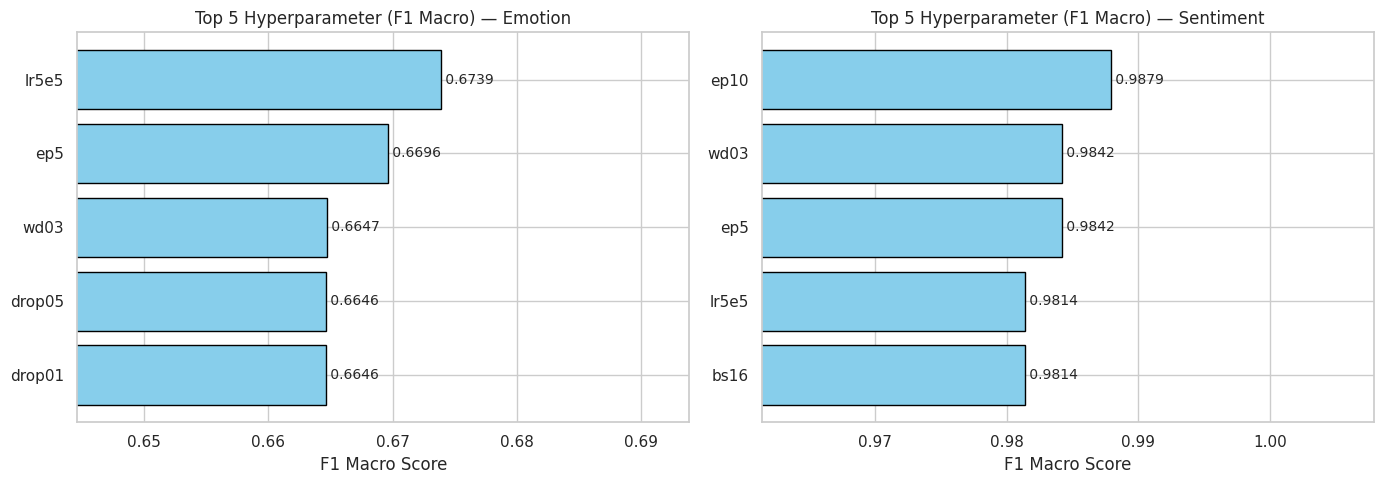

✅ Plot Top 5 Hyperparameter disimpan ke /kaggle/working/s3_hp_comparison.png


In [9]:
# Visualisasi: Top 5 Hyperparameter Configs untuk IndoBERT
if not df_results_s3.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, task in zip(axes, ["Emotion", "Sentiment"]):
        sub = df_results_s3[df_results_s3["Task"] == task]
        
        if not sub.empty:
            # Ambil 5 settingan HP dengan skor tertinggi
            top_hps = sub.sort_values("f1_macro", ascending=True).tail(5) 
            
            # Bikin Bar Chart
            bars = ax.barh(top_hps["HP"], top_hps["f1_macro"], color='skyblue', edgecolor='black')
            ax.set_title(f"Top 5 Hyperparameter (F1 Macro) — {task}")
            ax.set_xlabel("F1 Macro Score")
            
            min_f1 = top_hps["f1_macro"].min()
            ax.set_xlim(max(0, min_f1 - 0.02), top_hps["f1_macro"].max() + 0.02)
            
            for bar in bars:
                ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
                        f' {bar.get_width():.4f}', 
                        va='center', ha='left', fontsize=10)

    plt.tight_layout()
    plt.savefig("/kaggle/working/s3_hp_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Plot Top 5 Hyperparameter disimpan ke /kaggle/working/s3_hp_comparison.png")

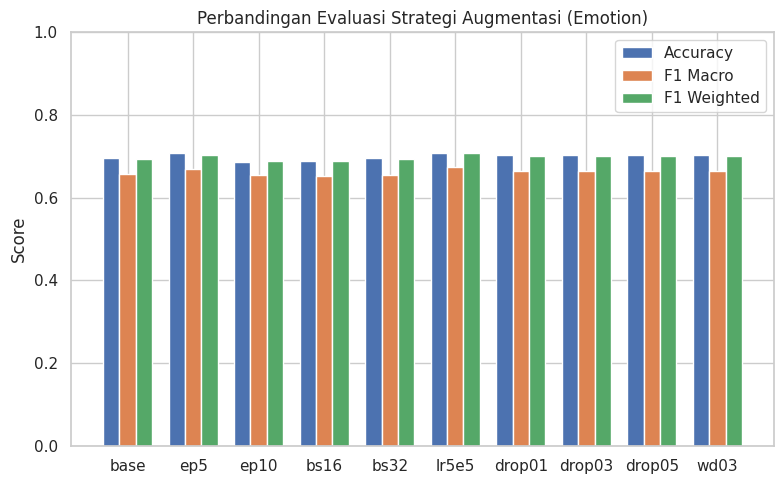

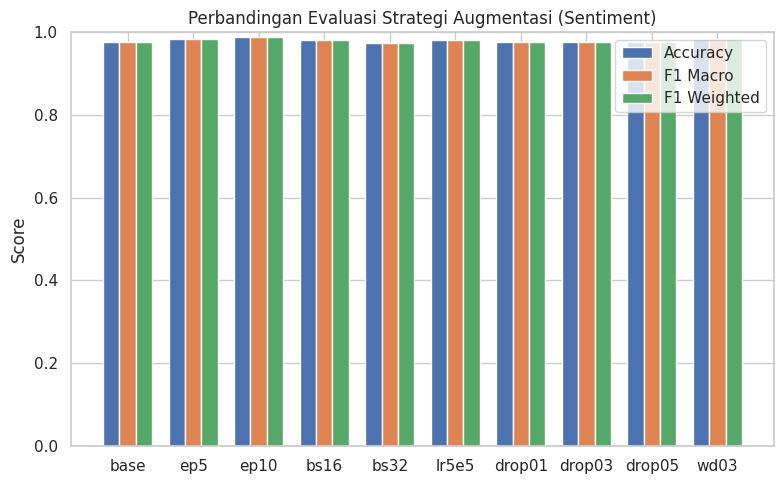

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# PERBANDINGAN HASIL AUGMENTASI
# ==========================

for task_name in S3_RESULTS.keys():

    rows = []

    for hp_label in S3_RESULTS[task_name]:
        for model_alias in S3_RESULTS[task_name][hp_label]:

            m = S3_RESULTS[task_name][hp_label][model_alias]["metrics"]

            rows.append({
                "Branch": hp_label.replace("_", "\n"),
                "Accuracy": m["accuracy"],
                "F1 Macro": m["f1_macro"],
                "F1 Weighted": m["f1_weighted"]
            })

    df_plot = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(8,5))

    x = range(len(df_plot))
    w = 0.25

    ax.bar([i-w for i in x], df_plot["Accuracy"], width=w, label="Accuracy")
    ax.bar(x, df_plot["F1 Macro"], width=w, label="F1 Macro")
    ax.bar([i+w for i in x], df_plot["F1 Weighted"], width=w, label="F1 Weighted")

    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["Branch"])

    ax.set_ylim(0,1)
    ax.set_ylabel("Score")
    ax.set_title(f"Perbandingan Evaluasi Strategi Augmentasi ({task_name})")
    ax.legend()

    plt.tight_layout()
    plt.show()


Membuat Word Cloud berdasarkan hasil PREDIKSI Best Model Skenario 3...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

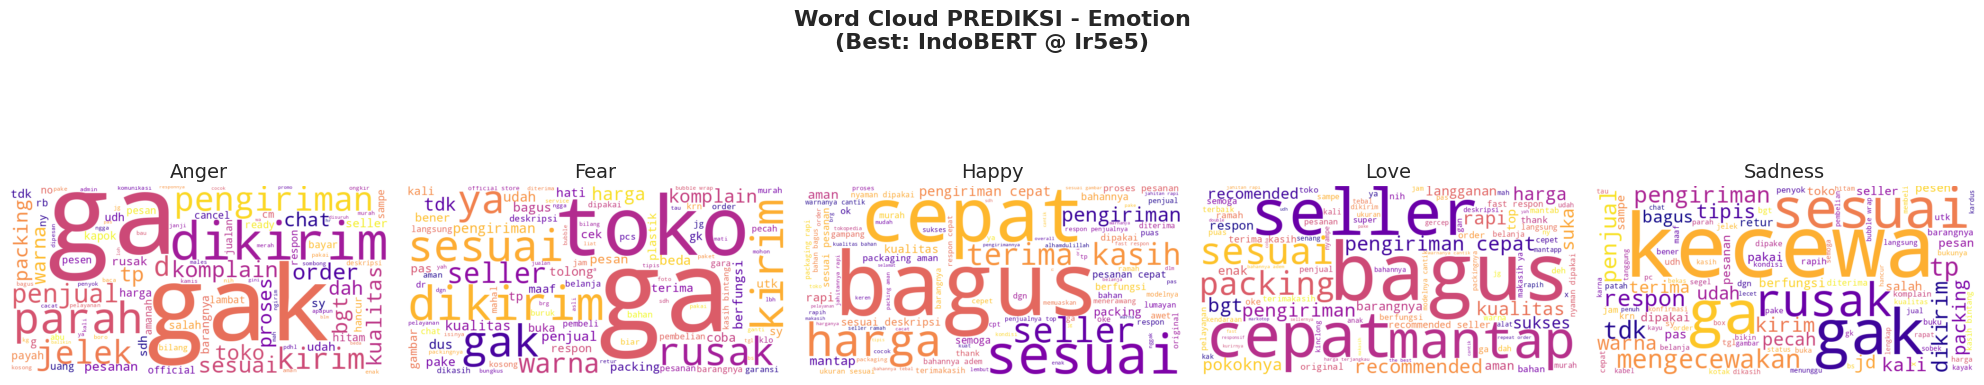

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

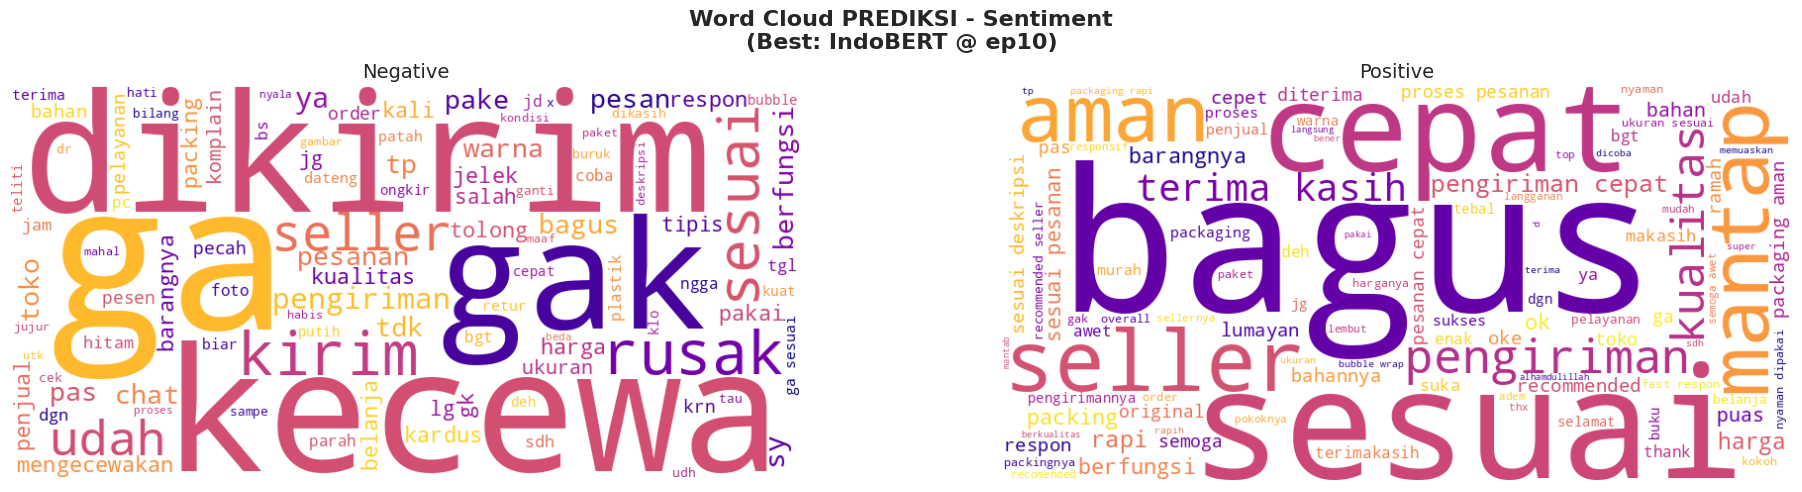

In [11]:
# ==========================================
# 1. WORD CLOUD HASIL PREDIKSI MODEL TERBAIK SKENARIO 2
# ==========================================
pip("wordcloud", "nltk")
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

nltk.download('stopwords', quiet=True)
indo_stopwords = set(stopwords.words('indonesian'))
custom_stopwords = {
    "yg", "nya", "di", "ke", "dari", "dan", "ini", "itu", "untuk", "dengan",
    "yang", "ada", "juga", "sudah", "buat", "karena", "kalo", "aku", "saya",
    "aja", "sama", "barang", "produk", "beli", "banget", "sih", "kok"
}
indo_stopwords = indo_stopwords.union(custom_stopwords)

print("\nMembuat Word Cloud berdasarkan hasil PREDIKSI Best Model Skenario 3...")

for task_name, (text_col, label_col, label_names) in TASKS.items():
    best_dir = f"/kaggle/working/best_model_s3_{task_name}"

    if not os.path.exists(best_dir):
        print(f"Directory {best_dir} tidak ditemukan. Lewati task {task_name}.")
        continue

    texts = df[text_col].values
    labels = df[label_col].values
    _, _, test_texts, _, _, test_labels = make_splits(texts, labels)

    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer)
    trainer = Trainer(model=model)

    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)

    df_pred = pd.DataFrame({
        "text": test_texts,
        "pred_label": [label_names[p] for p in preds]
    })

    fig, axes = plt.subplots(1, len(label_names), figsize=(20, 5))
    hp_label = BEST_MODEL_TRACKER[task_name]["hp_label"]

    fig.suptitle(
        f"Word Cloud PREDIKSI - {task_name}\n"
        f"(Best: {BEST_MODEL_TRACKER[task_name]['model_alias']} @ {hp_label})",
        fontsize=16,
        fontweight="bold"
    )

    if len(label_names) == 1:
        axes = [axes]

    for ax, cls in zip(axes, label_names):
        text_data = " ".join(df_pred[df_pred["pred_label"] == cls]["text"].tolist())

        if text_data.strip() == "":
            ax.set_title(f"{cls}\n(Tidak diprediksi)", fontsize=14, color='red')
            ax.axis("off")
            continue

        wc = WordCloud(width=800, height=400, background_color='white',
                       colormap='plasma', max_words=100,
                       stopwords=indo_stopwords).generate(text_data)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(cls, fontsize=14)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    del model, tokenizer, trainer, test_ds, df_pred
    free_memory()


Memproses Crosstab Prediksi (Best Hyperparameter Skenario 3)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

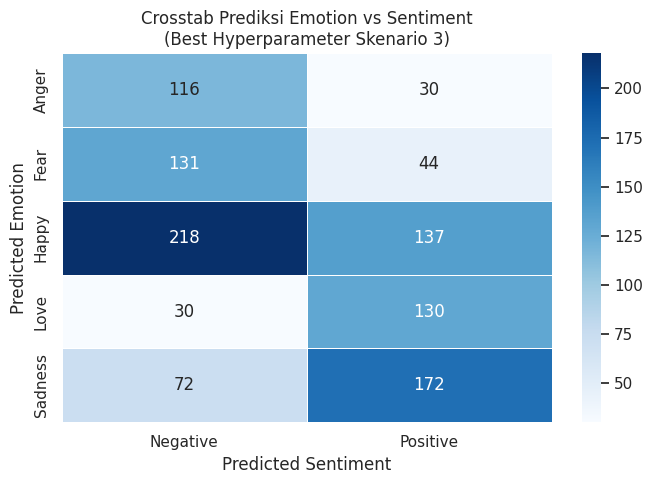

In [12]:
# ==========================================
# CROSSTAB PREDIKSI (Best Hyperparameter Skenario 3)
# ==========================================

print("\nMemproses Crosstab Prediksi (Best Hyperparameter Skenario 3)...")

preds_dict = {}

for task_name, (_, _, label_names) in TASKS.items():

    best_dir = f"/kaggle/working/best_model_s3_{task_name}"

    if not os.path.exists(best_dir):
        print(f"Directory {best_dir} tidak ditemukan.")
        continue

    texts = df["text_clean"].values
    labels = df[f"label_{task_name.lower()}"].values

    _, _, test_texts, _, _, test_labels = make_splits(texts, labels)

    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer)

    trainer = Trainer(model=model)

    preds_raw = trainer.predict(test_ds)

    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]

    preds = np.argmax(preds_logits, axis=-1)

    preds_dict[task_name] = [label_names[p] for p in preds]

    del model, tokenizer, trainer, test_ds
    free_memory()

df_pred = pd.DataFrame({
    "Pred_Emotion": preds_dict["Emotion"],
    "Pred_Sentiment": preds_dict["Sentiment"]
})

cross_tab = pd.crosstab(
    df_pred["Pred_Emotion"],
    df_pred["Pred_Sentiment"]
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=.5
)

plt.title("Crosstab Prediksi Emotion vs Sentiment\n(Best Hyperparameter Skenario 3)")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Predicted Emotion")

plt.tight_layout()
plt.show()

Memuat model terbaik Skenario 3...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

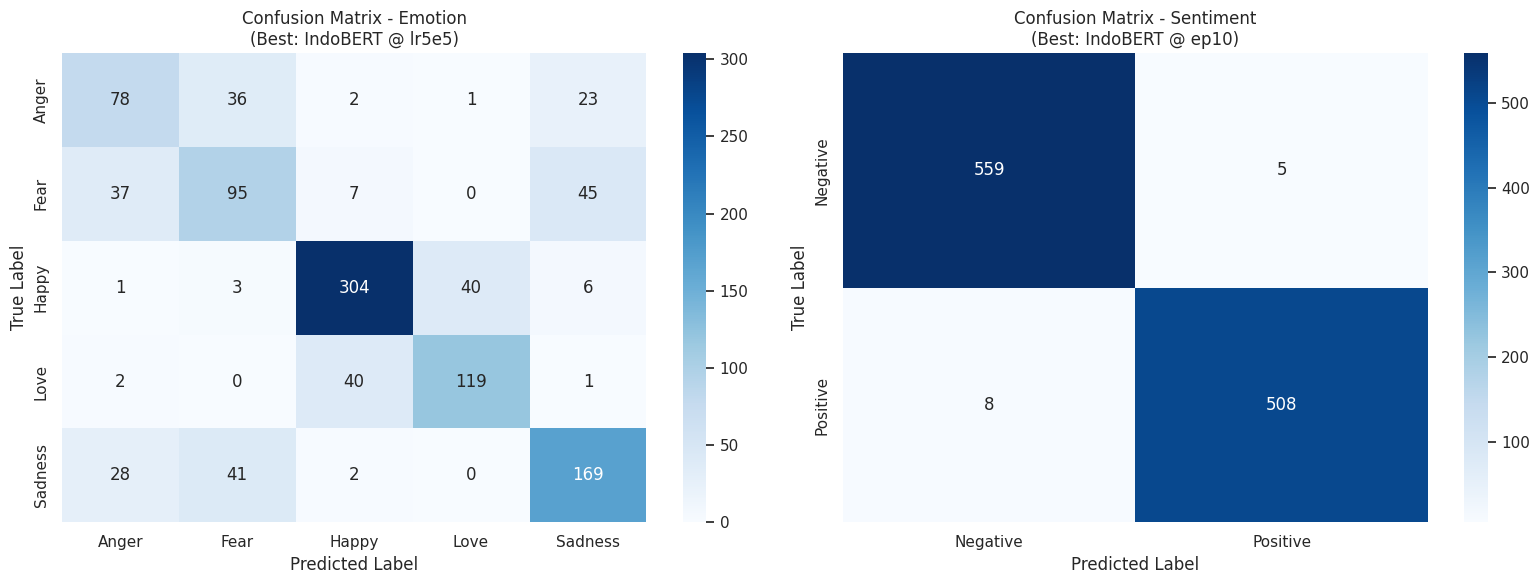

In [13]:
# ==========================================
# 3. CONFUSION MATRIX (Best Models Skenario 3)
# ==========================================
print("Memuat model terbaik Skenario 3...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (task_name, (text_col, label_col, label_names)) in enumerate(TASKS.items()):
    best_dir = f"/kaggle/working/best_model_s3_{task_name}"

    if not os.path.exists(best_dir):
        print(f"Directory {best_dir} tidak ditemukan. Lewati task {task_name}.")
        continue

    texts = df[text_col].values
    labels = df[label_col].values
    _, _, test_texts, _, _, test_labels = make_splits(texts, labels)

    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer)
    trainer = Trainer(model=model)

    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)

    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[idx])

    hp_label = BEST_MODEL_TRACKER[task_name]["hp_label"]

    axes[idx].set_title(
        f"Confusion Matrix - {task_name}\n"
        f"(Best: {BEST_MODEL_TRACKER[task_name]['model_alias']} @ {hp_label})"
    )
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

    del model, tokenizer, trainer, test_ds
    free_memory()

plt.tight_layout()
plt.show()